In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Load the dataset
df = pd.read_csv('/content/Global_Superstore.csv', encoding='latin1')

# Display basic information
print("Initial Data Overview:")
df.info()

Initial Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product 


Missing Values in Each Column:
 Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64


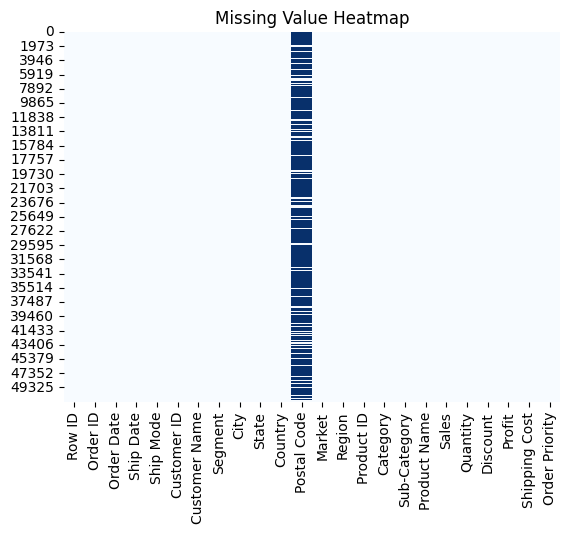

In [45]:
# 1. Handling Missing Values

print("\nMissing Values in Each Column:\n", df.isnull().sum())

# Visualize missing values
sns.heatmap(df.isnull(), cbar=False, cmap="Blues")
plt.title("Missing Value Heatmap")
plt.show()

In [46]:
# Fill missing Postal Code values with median
df['Postal Code'] = df['Postal Code'].fillna(
    df['Postal Code'].median()
)

In [47]:
print("\nMissing Values After Handling:\n", df.isnull().sum())


Missing Values After Handling:
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
City              0
State             0
Country           0
Postal Code       0
Market            0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
Shipping Cost     0
Order Priority    0
dtype: int64


In [48]:
# 2. Removing Duplicates

initial_rows = df.shape[0]

df.drop_duplicates(inplace=True)

print(f"\nRemoved {initial_rows - df.shape[0]} duplicate rows.")


Removed 0 duplicate rows.


In [49]:
# 3. Data Type Conversion

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print("\nData Types After Conversion:")
print(df[['Order Date', 'Ship Date']].dtypes)


Data Types After Conversion:
Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


/tmp/ipykernel_1248/2871993451.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Order Date'] = pd.to_datetime(df['Order Date'])
/tmp/ipykernel_1248/2871993451.py:4: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Ship Date'] = pd.to_datetime(df['Ship Date'])


In [50]:
# 4. Ensuring Categorical Consistency

categorical_cols = [
    'Ship Mode',
    'Segment',
    'City',
    'State',
    'Country',
    'Market',
    'Region',
    'Category',
    'Sub-Category',
    'Order Priority'
]

for col in categorical_cols:
    df[col] = df[col].str.strip().str.title()

In [51]:
print("\nUnique Ship Modes:")
print(df['Ship Mode'].unique())

print("\nUnique Categories:")
print(df['Category'].unique())

print("\nUnique Segments:")
print(df['Segment'].unique())


Unique Ship Modes:
['Same Day' 'Second Class' 'First Class' 'Standard Class']

Unique Categories:
['Technology' 'Furniture' 'Office Supplies']

Unique Segments:
['Consumer' 'Corporate' 'Home Office']


In [52]:
# 5. Normalization

min_max_scaler = MinMaxScaler()

scale_cols = [
    'Sales',
    'Quantity',
    'Profit'
]

df[scale_cols] = min_max_scaler.fit_transform(
    df[scale_cols]
)

In [53]:
scaler = StandardScaler()

df[['Shipping Cost']] = scaler.fit_transform(
    df[['Shipping Cost']]
)

In [54]:
# 6. Final Overview

print("\nCleaned Data Summary:")
print(df.info())

print("\nFirst 5 Rows:")
print(df.head())


Cleaned Data Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51290 non-null  int64         
 1   Order ID        51290 non-null  object        
 2   Order Date      51290 non-null  datetime64[ns]
 3   Ship Date       51290 non-null  datetime64[ns]
 4   Ship Mode       51290 non-null  object        
 5   Customer ID     51290 non-null  object        
 6   Customer Name   51290 non-null  object        
 7   Segment         51290 non-null  object        
 8   City            51290 non-null  object        
 9   State           51290 non-null  object        
 10  Country         51290 non-null  object        
 11  Postal Code     51290 non-null  float64       
 12  Market          51290 non-null  object        
 13  Region          51290 non-null  object        
 14  Product ID      51290 non-null 